In [ ]:
EDA

1. 토큰 길이 분포

Matplotlib is building the font cache; this may take a moment.


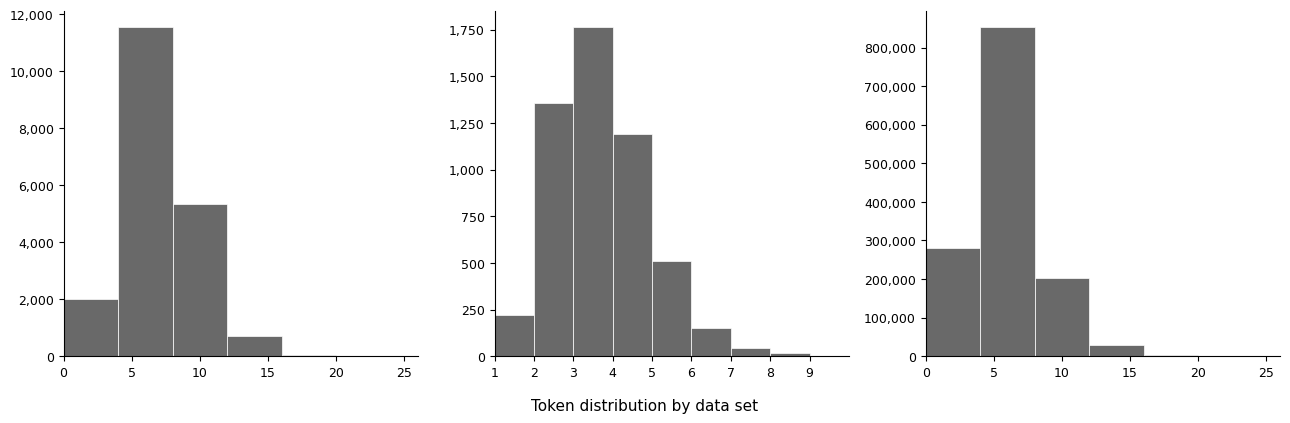

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

wellness = pd.read_csv("cleaned_wellness.csv")
chatbot  = pd.read_csv("cleaned_chatbot.csv")
subject  = pd.read_csv("cleaned_subject.csv")

def get_lengths(df):
    return df['utterance'].dropna().apply(lambda x: len(str(x).split())).tolist()

wl = get_lengths(wellness)
cl = get_lengths(chatbot)
sl = get_lengths(subject)

# wellness/subject: x눈금 5칸 간격, 막대 4칸마다
# chatbot:          x눈금 1칸 간격, 막대 1칸마다
configs = [
    (wl, [0,4,8,12,16,20,24,26], 'Wellness', [0,5,10,15,20,25]),
    (cl, [1,2,3,4,5,6,7,8,9,10], 'Chatbot',  [1,2,3,4,5,6,7,8,9]),
    (sl, [0,4,8,12,16,20,24,26], 'Subject',  [0,5,10,15,20,25]),
]

BAR_COLOR = '#696969'

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (data, bins, title, xticks) in zip(axes, configs):
    counts, edges = np.histogram(data, bins=bins)

    widths = np.diff(edges)
    ax.bar(edges[:-1], counts, width=widths, align='edge',
           color=BAR_COLOR, edgecolor='white', linewidth=0.5)

    ax.set_xticks(xticks)
    ax.set_xticklabels([str(t) for t in xticks], fontsize=9)
    ax.set_xlim(edges[0], edges[-1])

    ax.yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
    )
    ax.tick_params(axis='both', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.text(0.5, -0.04, 'Token distribution by data set',
         ha='center', fontsize=11)

plt.tight_layout()
plt.savefig("fig4_token_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

2. 워드클라우드

세련된 색조합으로 워드클라우드 생성 중...


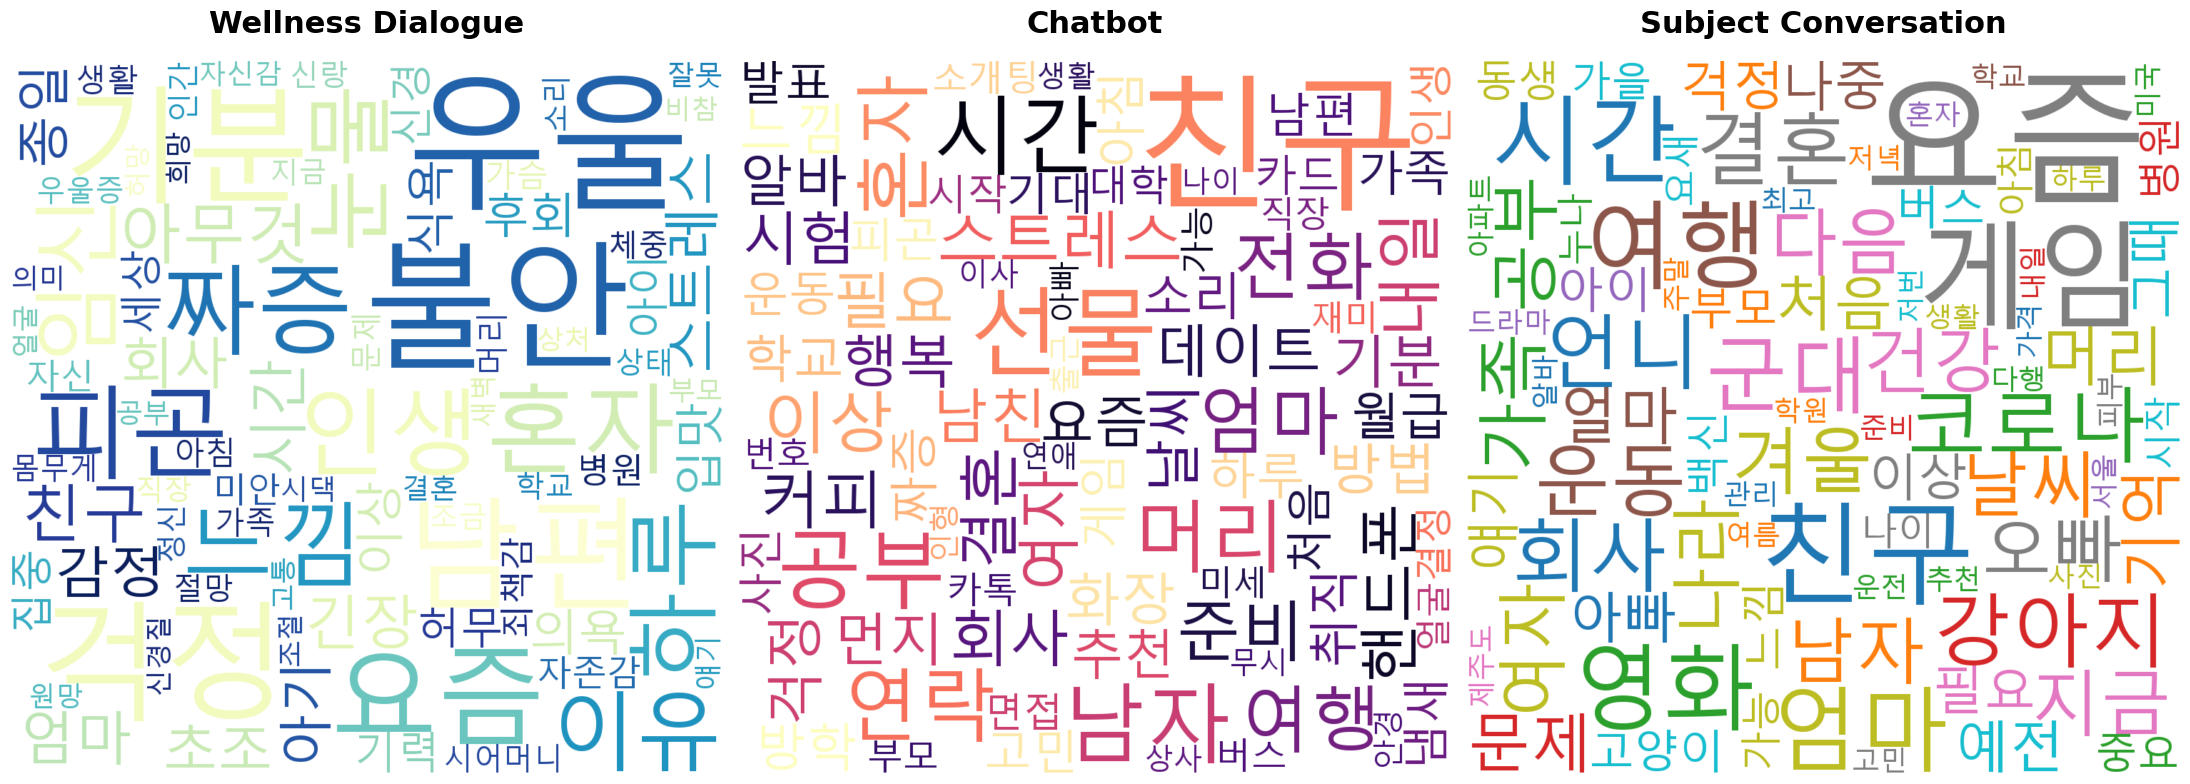

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from kiwipiepy import Kiwi
from collections import Counter

# 1. Kiwi 및 데이터 로드 (기존과 동일)
kiwi = Kiwi()
df_wellness = pd.read_csv('cleaned_wellness.csv')
df_subject = pd.read_csv('cleaned_subject.csv')
df_chatbot = pd.read_csv('cleaned_chatbot.csv')

# 2. 명사 추출 함수 (기존 로직 유지)
def get_pure_nouns_fixed(df, column_name='utterance'):
    sentences = df[column_name].astype(str).tolist()
    nouns = []
    for sent in sentences:
        if not sent.strip(): continue
        analysis = kiwi.analyze(sent)
        for token in analysis[0][0]:
            if token.tag in ['NNG', 'NNP'] and len(token.form) > 1:
                nouns.append(token.form)
    
    # 가독성을 저해하는 일반적인 단어들을 추가로 필터링
    stopwords = ['생각', '오늘', '하나', '무엇', '때문', '정도', '그거', '이번', '사람', '마음', '대해', '어디', '어떻게', '키키']
    filtered_nouns = [n for n in nouns if n not in stopwords]
    return Counter(filtered_nouns)

# 3. 시각화 설정
fig, axes = plt.subplots(1, 3, figsize=(22, 10)) # 가로 크기를 조금 더 키움

datasets = [df_wellness, df_chatbot, df_subject]
titles = ['Wellness Dialogue', 'Chatbot', 'Subject Conversation']

# [수정 포인트] 각 데이터셋에 어울리는 컬러맵 설정
cmaps = ['YlGnBu', 'magma', 'tab10'] 

print("세련된 색조합으로 워드클라우드 생성 중...")

for i, df in enumerate(datasets):
    counts = get_pure_nouns_fixed(df)
    
    if not counts:
        continue

    # [수정 포인트] 가독성을 극대화하는 옵션들 추가
    wc = WordCloud(
        font_path="malgun.ttf", 
        background_color="white", # 깔끔한 흰색 배경
        width=1000, height=1000,   # 해상도 높임
        max_words=80,             # 너무 많으면 지저분하므로 핵심 80개만
        colormap=cmaps[i],        # 테마별 색상 적용
        prefer_horizontal=0.8,    # 글자를 최대한 가로로 배치 (가독성 UP)
        max_font_size=200,         # 가장 큰 글자 크기 제한
        min_font_size=10,
        random_state=42           # 매번 돌릴 때마다 배치가 변하지 않게 고정
    ).generate_from_frequencies(counts)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(titles[i], fontsize=22, pad=20, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

3. 형태소(POS) 비율 분석

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from kiwipiepy import Kiwi
from collections import Counter

# ==========================================
# 1. 한글 폰트 깨짐 해결 (윈도우 데스크탑 전용)
# ==========================================
# Seaborn 스타일을 먼저 설정해야 폰트 설정이 초기화되지 않습니다.
sns.set_style("whitegrid")

# 맑은 고딕 전체 경로 지정
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

# Matplotlib 전역 폰트 설정 적용
plt.rc('font', family=font_name)
plt.rcParams['font.family'] = font_name
plt.rc('axes', unicode_minus=False)  # 마이너스 기호 깨짐 방지

# 고해상도 설정
%config InlineBackend.figure_format = 'retina'

print(f"시스템 폰트 설정 완료: {font_name}")

# ==========================================
# 2. Kiwi 초기화 및 데이터 로드
# ==========================================
kiwi = Kiwi()
files = {
    "Wellness": "cleaned_wellness.csv",
    "Chatbot": "cleaned_chatbot.csv",
    "Subject": "cleaned_subject.csv"
}

def analyze_pos_ratio_fixed(df, name, column_name='utterance'):
    # 데이터를 리스트로 변환하고 결측치 제거
    sentences = df[column_name].dropna().astype(str).tolist()
    pos_counts = Counter()
    total_tokens = 0

    print(f"[{name}] 데이터 분석 중... 잠시만 기다려주세요.")

    # 문장별로 형태소 분석 수행 (모든 Kiwi 버전 호환)
    for sent in sentences:
        if not sent.strip(): continue
        
        result = kiwi.analyze(sent)
        
        # result[0][0]은 가장 확률이 높은 분석 결과의 토큰 리스트
        for token in result[0][0]:
            tag = token.tag
            total_tokens += 1
            
            # 품사 카테고리 분류 (주요 5대 품사 기준)
            if tag.startswith('N'): # 명사 (일반, 고유, 대명사 등)
                pos_counts['Nouns'] += 1
            elif tag == 'VV': # 동사
                pos_counts['Verbs'] += 1
            elif tag == 'VA': # 형용사
                pos_counts['Adjectives'] += 1
            elif tag.startswith('J'): # 조사
                pos_counts['Particles'] += 1
            elif tag.startswith('E'): # 어미
                pos_counts['Endings'] += 1
            else:
                pos_counts['Others'] += 1

    # 비율(%) 계산
    if total_tokens == 0: return None
    ratios = {category: (count / total_tokens) * 100 for category, count in pos_counts.items()}
    ratios['Dataset'] = name
    return ratios

# ==========================================
# 3. 분석 실행 및 데이터 정리
# ==========================================
all_ratios = []
for name, file in files.items():
    try:
        df = pd.read_csv(file)
        res = analyze_pos_ratio_fixed(df, name)
        if res: all_ratios.append(res)
    except Exception as e:
        print(f"{name} 파일 처리 중 오류 발생: {e}")

# 결과 데이터프레임 생성 및 순서 정렬
ratio_df = pd.DataFrame(all_ratios).set_index('Dataset')
plot_df = ratio_df[['Nouns', 'Verbs', 'Adjectives', 'Particles', 'Endings']]

# ==========================================
# 4. 시각화 (Stacked Bar Chart)
# ==========================================
fig, ax = plt.subplots(figsize=(14, 8))

# 누적 막대 그래프 그리기
plot_df.plot(kind='bar', stacked=True, ax=ax, colormap='Pastel1', edgecolor='0.3')

# 그래프 제목 및 라벨 설정 (한글 확인 필수)
ax.set_title('데이터셋별 품사(POS) 분포 비교 분석', fontsize=20, pad=25, fontweight='bold')
ax.set_ylabel('구성 비율 (%)', fontsize=14)
ax.set_xlabel('데이터셋 종류', fontsize=14)
ax.set_xticklabels(plot_df.index, rotation=0, fontsize=12)

# 범례 설정
ax.legend(title='품사 카테고리', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11)

# 막대 내부 수치(%) 표시
for p in ax.patches:
    h = p.get_height()
    if h > 3: # 비율이 3% 이상인 경우에만 텍스트 표시
        ax.text(p.get_x() + p.get_width()/2., 
                p.get_y() + h/2., 
                f'{h:.1f}%', 
                ha='center', 
                va='center', 
                fontsize=10, 
                fontweight='bold',
                color='#333333')

plt.tight_layout()
plt.show()

시스템 폰트 설정 완료: Malgun Gothic
[Wellness] 데이터 분석 중... 잠시만 기다려주세요.
[Chatbot] 데이터 분석 중... 잠시만 기다려주세요.
[Subject] 데이터 분석 중... 잠시만 기다려주세요.


4. 어휘 다양성 지수(TTR:Type-Token Ratio)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def get_ws_ttr(df, column_name='utterance'):
    """
    공백(Whitespace) 기준으로 분리된 어절의 TTR을 계산합니다.
    """
    # 1. 텍스트 데이터 추출 (결측치 제거 및 문자열 변환)
    texts = df[column_name].dropna().astype(str).tolist()
    
    # 2. 전체 어절(Tokens) 리스트 생성
    all_tokens = []
    for text in texts:
        all_tokens.extend(text.split())
    
    # 3. 고유 어절(Types) 추출
    unique_types = set(all_tokens)
    
    # 4. TTR 계산 (Unique Types / Total Tokens)
    total_tokens_count = len(all_tokens)
    unique_types_count = len(unique_types)
    ttr = unique_types_count / total_tokens_count if total_tokens_count > 0 else 0
    
    return {
        'Total Tokens': total_tokens_count,
        'Unique Types': unique_types_count,
        'TTR': round(ttr, 4)
    }

# 데이터 로드
files = {
    "Wellness": "cleaned_wellness.csv",
    "Chatbot": "cleaned_chatbot.csv",
    "Subject": "cleaned_subject.csv"
}

results = []
for name, file in files.items():
    try:
        df = pd.read_csv(file)
        stats = get_ws_ttr(df)
        stats['Dataset'] = name
        results.append(stats)
    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: {file}")

# 결과 출력 및 시각화
ttr_df = pd.DataFrame(results).set_index('Dataset')
print(ttr_df)

# 시각화
ttr_df['TTR'].plot(kind='bar', color='#4A90E2', figsize=(8, 5), rot=0)
plt.title('Type-Token Ratio (Whitespace Unit)', fontsize=14)
plt.ylabel('TTR Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

5. 가독성 및 문장 구조 분석

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from kiwipiepy import Kiwi

# 1. Kiwi 초기화 및 데이터 로드
kiwi = Kiwi()

def analyze_structure(df, name, column_name='utterance'):
    texts = df[column_name].dropna().astype(str).tolist()
    
    stats = []
    for sent in texts:
        # 가독성 기본 지표
        char_len = len(sent)          # 글자 수
        word_len = len(sent.split())  # 어절 수
        
        # 형태소 분석 및 복잡도
        tokens = kiwi.tokenize(sent)
        morph_count = len(tokens)     # 형태소 개수
        
        # 문장 유형 파악 (의문문 여부)
        is_question = 1 if '?' in sent or any(t.tag == 'EF' and t.form in ['니', '까', '죠', '가요'] for t in tokens) else 0
        
        stats.append({
            'char_len': char_len,
            'word_len': word_len,
            'morph_complexity': morph_count / word_len if word_len > 0 else 0, # 어절당 형태소 수
            'is_question': is_question
        })
    
    res_df = pd.DataFrame(stats)
    return {
        'Dataset': name,
        'Avg Char Len': res_df['char_len'].mean(),
        'Avg Word Count': res_df['word_len'].mean(),
        'Morph Complexity': res_df['morph_complexity'].mean(),
        'Question Ratio (%)': res_df['is_question'].mean() * 100
    }

# 2. 데이터셋별 실행
files = {
    "Wellness": "cleaned_wellness.csv",
    "Chatbot": "cleaned_chatbot.csv",
    "Subject": "cleaned_subject.csv"
}

results = []
for name, file in files.items():
    df = pd.read_csv(file)
    results.append(analyze_structure(df, name))

# 3. 결과 정리 및 시각화
summary_df = pd.DataFrame(results).set_index('Dataset')
print(summary_df)

# 시각화: 문장 길이와 의문문 비율 비교
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

summary_df['Avg Char Len'].plot(kind='bar', ax=axes[0], color=['#ff9999','#66b3ff','#99ff99'], title='Average Sentence Length (Chars)')
summary_df['Question Ratio (%)'].plot(kind='bar', ax=axes[1], color=['#ff9999','#66b3ff','#99ff99'], title='Question Sentence Ratio (%)')

plt.tight_layout()
plt.show()

ModuleNotFoundError: No module named 'seaborn'

6. 토픽 모델링(LDA) 

In [ ]:
import pandas as pd
from kiwipiepy import Kiwi
from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# 1. 전처리 함수 (명사 추출 - 불용어 필터 제거 버전)
kiwi = Kiwi()
def preprocess_for_lda(df, column_name='utterance'):
    texts = df[column_name].dropna().astype(str).tolist()
    tokenized_data = []
    
    for sent in texts:
        # 명사(NNG, NNP)만 추출, 2글자 이상인 경우만 리스트에 담음
        res = [t.form for t in kiwi.tokenize(sent) if t.tag in ['NNG', 'NNP'] and len(t.form) > 1]
        
        # [수정] 불용어 체크 과정을 생략하고 바로 추가합니다.
        if res:
            tokenized_data.append(res)
    return tokenized_data

# 2. 데이터 로드 및 토큰화
df = pd.read_csv('cleaned_wellness.csv')
processed_docs = preprocess_for_lda(df)

# 3. Gensim용 사전(Dictionary) 및 코퍼스(Corpus) 생성
dictionary = corpora.Dictionary(processed_docs)

# [팁] 불용어를 안 쓰는 대신, 너무 흔한 단어를 이 단계에서 걸러낼 수 있습니다.
# no_above=0.5는 전체 문서의 50% 이상에서 등장하는 단어(너무 흔한 단어)를 제거합니다.
dictionary.filter_extremes(no_below=2, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

# 4. LDA 모델 학습
num_topics = 5
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    passes=15,
    random_state=42,
    iterations=400
)

# 5. 결과 출력
print(f"\n[ LDA Topics for {num_topics} clusters ]")
for i, topic in lda_model.print_topics():
    print(f"Topic {i}: {topic}")

# 6. 시각화 저장
vis_data = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.save_html(vis_data, 'lda_visualization_wellness_raw.html')
print("\n시각화 파일 'lda_visualization_wellness_raw.html'이 저장되었습니다.")

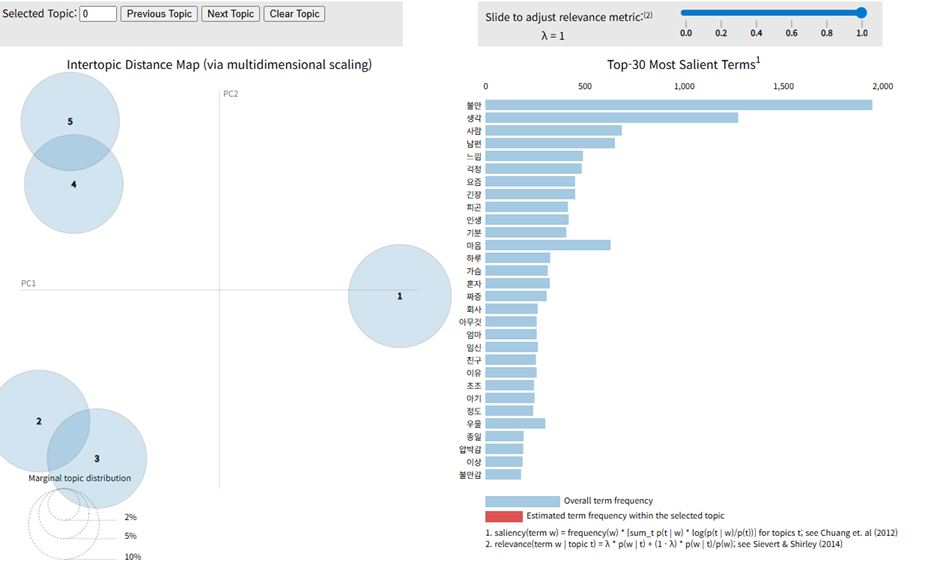

In [ ]:
import pandas as pd
from kiwipiepy import Kiwi
from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# 1. 전처리 함수 (명사 추출 - 불용어 필터 제거 버전)
kiwi = Kiwi()
def preprocess_for_lda(df, column_name='utterance'):
    texts = df[column_name].dropna().astype(str).tolist()
    tokenized_data = []
    
    for sent in texts:
        # 명사(NNG, NNP)만 추출, 2글자 이상인 경우만 리스트에 담음
        res = [t.form for t in kiwi.tokenize(sent) if t.tag in ['NNG', 'NNP'] and len(t.form) > 1]
        
        # [수정] 불용어 체크 과정을 생략하고 바로 추가합니다.
        if res:
            tokenized_data.append(res)
    return tokenized_data

# 2. 데이터 로드 및 토큰화
df = pd.read_csv('cleaned_chatbot.csv')
processed_docs = preprocess_for_lda(df)

# 3. Gensim용 사전(Dictionary) 및 코퍼스(Corpus) 생성
dictionary = corpora.Dictionary(processed_docs)

# [팁] 불용어를 안 쓰는 대신, 너무 흔한 단어를 이 단계에서 걸러낼 수 있습니다.
# no_above=0.5는 전체 문서의 50% 이상에서 등장하는 단어(너무 흔한 단어)를 제거합니다.
dictionary.filter_extremes(no_below=2, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

# 4. LDA 모델 학습
num_topics = 5
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    passes=15,
    random_state=42,
    iterations=400
)

# 5. 결과 출력
print(f"\n[ LDA Topics for {num_topics} clusters ]")
for i, topic in lda_model.print_topics():
    print(f"Topic {i}: {topic}")

# 6. 시각화 저장
vis_data = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.save_html(vis_data, 'lda_visualization_chatbot_raw.html')
print("\n시각화 파일 'lda_visualization_chatbot_raw.html'이 저장되었습니다.")

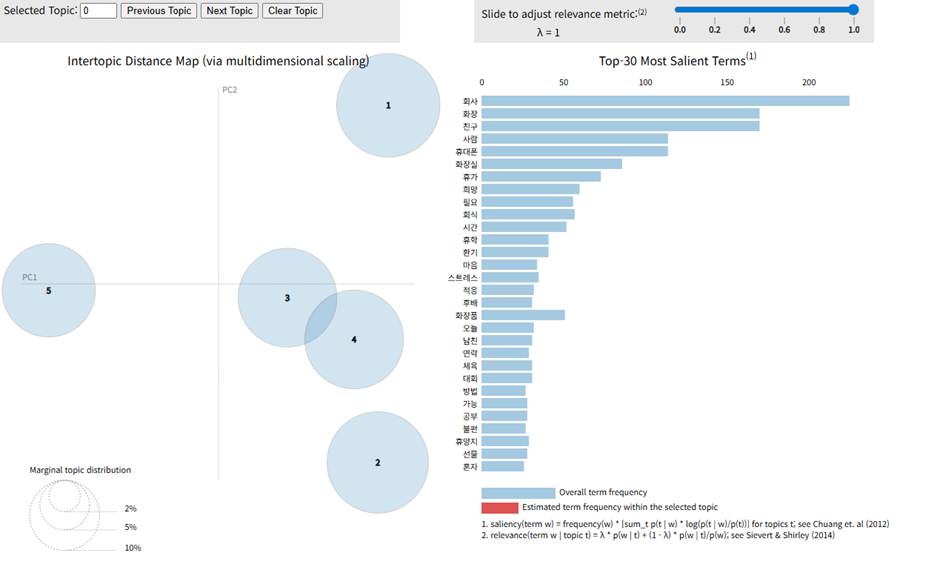

In [ ]:
import pandas as pd
from kiwipiepy import Kiwi
from gensim import corpora
from gensim.models import LdaModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# 1. 전처리 함수 (명사 추출 - 불용어 필터 제거 버전)
kiwi = Kiwi()
def preprocess_for_lda(df, column_name='utterance'):
    texts = df[column_name].dropna().astype(str).tolist()
    tokenized_data = []
    
    for sent in texts:
        # 명사(NNG, NNP)만 추출, 2글자 이상인 경우만 리스트에 담음
        res = [t.form for t in kiwi.tokenize(sent) if t.tag in ['NNG', 'NNP'] and len(t.form) > 1]
        
        # [수정] 불용어 체크 과정을 생략하고 바로 추가합니다.
        if res:
            tokenized_data.append(res)
    return tokenized_data

# 2. 데이터 로드 및 토큰화
df = pd.read_csv('cleaned_subject.csv')
processed_docs = preprocess_for_lda(df)

# 3. Gensim용 사전(Dictionary) 및 코퍼스(Corpus) 생성
dictionary = corpora.Dictionary(processed_docs)

# [팁] 불용어를 안 쓰는 대신, 너무 흔한 단어를 이 단계에서 걸러낼 수 있습니다.
# no_above=0.5는 전체 문서의 50% 이상에서 등장하는 단어(너무 흔한 단어)를 제거합니다.
dictionary.filter_extremes(no_below=2, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

# 4. LDA 모델 학습
num_topics = 5
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    passes=15,
    random_state=42,
    iterations=400
)

# 5. 결과 출력
print(f"\n[ LDA Topics for {num_topics} clusters ]")
for i, topic in lda_model.print_topics():
    print(f"Topic {i}: {topic}")

# 6. 시각화 저장
vis_data = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.save_html(vis_data, 'lda_visualization_subject_raw.html')
print("\n시각화 파일 'lda_visualization_subject_raw.html'이 저장되었습니다.")

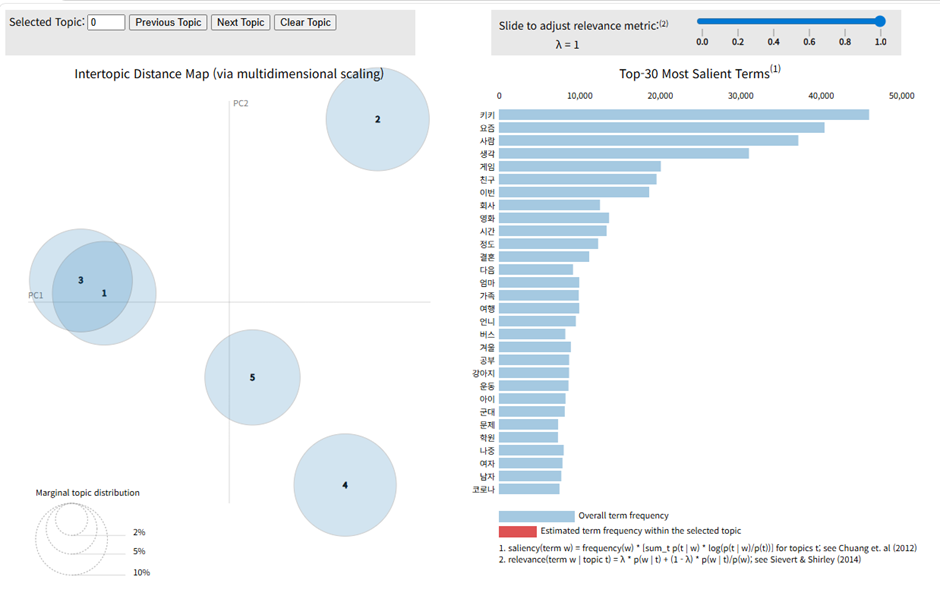

7. 문장 임베딩 시각화(t-SNE/UMAP)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from umap import UMAP

# 1. 모델 로드 (한국어 성능이 우수한 SBERT 모델)
model = SentenceTransformer('snunlp/KR-SBERT-V40K-klueNLI-augSTS')

# 2. 데이터 로드 및 샘플링
# 데이터가 너무 많으면 시각화가 지저분해지므로 각 데이터셋에서 500개씩 샘플링합니다.
def load_and_sample(filename, label, n=500):
    df = pd.read_csv(filename)
    sampled_df = df.sample(n=min(len(df), n), random_state=42)
    sampled_df['label'] = label
    return sampled_df[['utterance', 'label']]

df1 = load_and_sample('cleaned_wellness.csv', 'Wellness')
df2 = load_and_sample('cleaned_chatbot.csv', 'Chatbot')
df3 = load_and_sample('cleaned_subject.csv', 'Subject')

combined_df = pd.concat([df1, df2, df3], ignore_index=True)

# 3. 문장 임베딩 추출
print("문장 임베딩 추출 중... (시간이 다소 걸릴 수 있습니다)")
embeddings = model.encode(combined_df['utterance'].tolist(), show_progress_bar=True)

# 4. 차원 축소 실행 (t-SNE & UMAP)
print("차원 축소 실행 중...")
# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(embeddings)

# UMAP
umap_model = UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_results = umap_model.fit_transform(embeddings)

# 5. 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# t-SNE Plot
sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1], 
                hue=combined_df['label'], palette='Set1', ax=ax1, s=60, alpha=0.7)
ax1.set_title('t-SNE Visualization', fontsize=15)

# UMAP Plot
sns.scatterplot(x=umap_results[:, 0], y=umap_results[:, 1], 
                hue=combined_df['label'], palette='Set1', ax=ax2, s=60, alpha=0.7)
ax2.set_title('UMAP Visualization', fontsize=15)

plt.tight_layout()
plt.show()